# Case Study: Census

In [95]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

## U.S. National Park Service

Source: [Responsible Datasets in Context](https://www.responsible-datasets-in-context.com/posts/np-data/)

<img src="image.png" alt="photo of mountains and trees in Yosemite National Park" width="400 px" />

In [106]:
# load in data
# recreational visits to U.S. national parks in 2024
nps = Table.read_table('US-National-Parks_RecreationVisits_1979-2024.csv')
nps = nps.where("Year", 2024).drop("Year", "Region").sort("Visits", 2024)
nps.show(3)

Park,Park Code,State,Visits
Great Smoky Mountains NP,GRSM,TN,12191834
Zion NP,ZION,UT,4946592
Grand Canyon NP,GRCA,AZ,4919163


In [97]:
# `take`
# 1. what is the tenth most visited park?
# 2. how do I see just that row?
# 3. how do I see what is in the row after that?

nps.take(9, 10)

ParkName,UnitCode,State,Visits
Glacier NP,GLAC,MT,3208755
Joshua Tree NP,JOTR,CA,2991874


In [98]:
# more common: we will use `where` to pick out rows based on some condition
nps.where('State', 'CA').show(2)

ParkName,UnitCode,State,Visits
Yosemite NP,YOSE,CA,4121807
Joshua Tree NP,JOTR,CA,2991874


In [99]:
# ... or equivalently
nps.where('State', are.equal_to('CA')).show(2)

ParkName,UnitCode,State,Visits
Yosemite NP,YOSE,CA,4121807
Joshua Tree NP,JOTR,CA,2991874


In [100]:
# what about not equal to?
nps.where('State', are.not_equal_to('CA')).show(2)

ParkName,UnitCode,State,Visits
Great Smoky Mountains NP,GRSM,TN,12191834
Zion NP,ZION,UT,4946592


In [102]:
# more common: conditions with numerical values
nps.where('Visits', are.between(1e5, 1e6)).show(2)

ParkName,UnitCode,State,Visits
Saguaro NP,SAGU,AZ,946369
Canyonlands NP,CANY,UT,818492


In [ ]:
# what fraction of parks satisfy the above condition?
nps.where('Visits', are.between(1e5, 1e6)).num_rows / nps.num_rows

0.4603174603174603

### Discussion Questions

The table `nps` has columns:


| Park | Park Code | State | Visits |
| :-- | :-- | :-- | :-- |
| ... | ... | ... | ... |


#### a) Create an **array** containing the names of all California parks that had more than than 1 million visitors.

In [107]:
# ... code here ...
nps.where("State", "CA").where("Visits", are.above(1e6)).column("Park")

array(['Yosemite NP', 'Joshua Tree NP', 'Death Valley NP', 'Sequoia NP'],
      dtype='<U31')


#### b) After evaluating these two expressions in order, what's the result of the second one?

In [105]:
nps.drop('State')
nps.num_columns

4

<br/><br/><br/>

---

## Census ##

In [13]:
full = Table.read_table('nc-est2025-agesex-res.csv')
full.show(5)

SEX,AGE,ESTIMATESBASE2020,POPESTIMATE2020,POPESTIMATE2021,POPESTIMATE2022,POPESTIMATE2023,POPESTIMATE2024,POPESTIMATE2025
0,0,3719470,3691723,3572165,3680529,3653453,3617221,3618898
0,1,3764281,3750601,3697247,3602579,3719819,3700305,3642657
0,2,3841150,3826776,3756935,3727216,3642279,3766783,3725891
0,3,3916585,3888055,3832978,3786311,3766965,3689270,3791993
0,4,3984785,3976772,3894042,3861295,3824021,3811156,3712428


In [16]:
partial = full.select('SEX', 'AGE', 'POPESTIMATE2020', 'POPESTIMATE2025')
partial.show(6)

SEX,AGE,POPESTIMATE2020,POPESTIMATE2025
0,0,3691723,3618898
0,1,3750601,3642657
0,2,3826776,3725891
0,3,3888055,3791993
0,4,3976772,3712428
0,5,4005096,3833003


### Newborns

**DISCUSS**: How can there be different values for newborn babies vs. five year olds five years later?

In [ ]:
partial.column(3).take(5) / partial.column(2).take(0)

1.0382693934512421

In [38]:
# make column labels a bit nicer
us_pop = partial.relabeled(2, '2020').relabeled(3, '2025')
us_pop.show(5)

SEX,AGE,2020,2025
0,0,3691723,3618898
0,1,3750601,3642657
0,2,3826776,3725891
0,3,3888055,3791993
0,4,3976772,3712428


### Elderly

In [ ]:
us_pop.where('AGE', are.above_or_equal_to(98)).sort('AGE').show()

SEX,AGE,2020,2025
0,98,71153,92407
1,98,17393,27452
2,98,53760,64955
0,99,50624,64325
1,99,12189,18663
2,99,38435,45662
0,100,79080,119182
1,100,16931,31539
2,100,62149,87643
0,999,331578104,341784857


In [22]:
us_pop.where('SEX', 0).where('AGE', are.above_or_equal_to(98)).sort('AGE').show()

SEX,AGE,2020,2025
0,98,71153,92407
0,99,50624,64325
0,100,79080,119182
0,999,331578104,341784857


In [37]:
# how would we see the percent change by each age group?
percent_change = (us_pop.column('2025') - us_pop.column('2020')) / us_pop.column('2020')
us_pop_change = us_pop.with_column("Percent Change", percent_change).set_format("Percent Change", PercentFormatter)
us_pop_change.where('SEX', 0).where('AGE', are.above_or_equal_to(98)).sort('AGE').show()

SEX,AGE,2020,2025,Percent Change
0,98,71153,92407,29.87%
0,99,50624,64325,27.06%
0,100,79080,119182,50.71%
0,999,331578104,341784857,3.08%


**DISCUSS**: Why are there so many more elderly in 2025?

### 2025 Sex Ratios

In [ ]:
# focus just on 2025 population estimates, now by male/female
us_pop_2025 = us_pop.drop('2020')
us_pop_2025.show(3)

SEX,AGE,2025
0,0,3618898
0,1,3642657
0,2,3725891


In [ ]:
old = us_pop.where('AGE', 100)
old

SEX,AGE,2020,2025
0,100,79080,119182
1,100,16931,31539
2,100,62149,87643


In [42]:
all_ages = us_pop_2025.where('AGE', are.equal_to(999))
all_ages

SEX,AGE,2025
0,999,341784857
1,999,167737525
2,999,174047332


In [43]:
infants = us_pop_2025.where('AGE', are.equal_to(0))
infants

SEX,AGE,2025
0,0,3618898
1,0,1851154
2,0,1767744


In [47]:
females_all_rows = us_pop_2025.where('SEX', are.equal_to(2))
females = females_all_rows.where('AGE', are.not_equal_to(999))
females.show(3)

SEX,AGE,2025
2,0,1767744
2,1,1780068
2,2,1822877


In [48]:
males_all_rows = us_pop_2025.where('SEX', are.equal_to(1))
males = males_all_rows.where('AGE', are.not_equal_to(999))
males.show(3)

SEX,AGE,2025
1,0,1851154
1,1,1862589
1,2,1903014


How does the ratio of females to males vary by age?

In [49]:
f_to_m_ratios = females.column(2) / males.column(2)

ratios = Table().with_columns(
    'Age', females.column('AGE'),
    'F:M Ratio', f_to_m_ratios
)

ratios

Age,F:M Ratio
0,0.954942
1,0.955696
2,0.957889
3,0.959439
4,0.955978
5,0.957793
6,0.960912
7,0.959483
8,0.957975
9,0.958303


In [50]:
ratios.sort('Age', descending=True)

Age,F:M Ratio
100,2.77888
99,2.44666
98,2.36613
97,2.23542
96,2.10241
95,2.02206
94,1.92578
93,1.85083
92,1.76657
91,1.7137


#### Line Plot

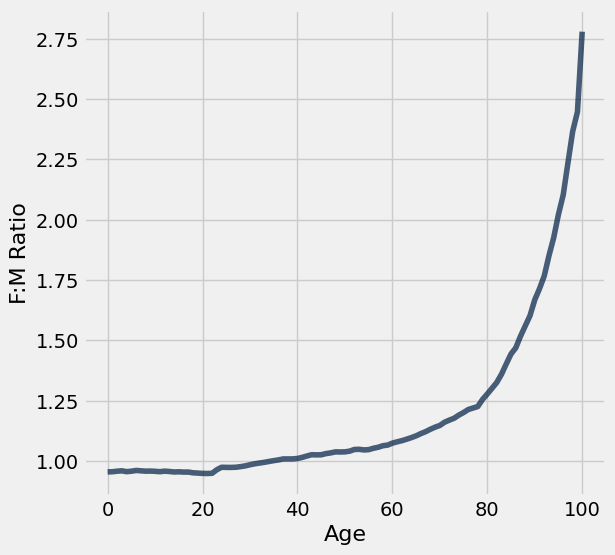

In [51]:
ratios.plot('Age', 'F:M Ratio')